In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

from time import time

import sys 
sys.path.append('..')

from PyESRSTM import QD, Electrode, units, rates, ESR, sum_rates, QME_matrix, QME, current
from PyESRSTM.postproces.dynamics import Bexch, Trel, Szacc


# Rate relations

Here we test some relations from the PRB paper. 

In [2]:
theta = 20/180*np.pi
eps= -30
U = 100
Nint = 1e4
B = 1*np.array([np.sin(theta),0,np.cos(theta)])
dot = QD(eps, U, np.array([0.5]), [B], np.array([[2.0, 2.0, 2.0]]))

Vdc= -30
Left = Electrode(Vdc, 0, 0, 1.25e-3, 1e-1, 4.5, Nint=Nint, Cutoff=1000, segments=[[dot.eps,30, Nint],[dot.U+dot.eps,30,Nint] ])
GLp, GLm = rates(dot, Left, 20, 0)
GL0 = GLp + GLm

PL = np.linspace(0,1,10)
Ge00e = np.empty_like(PL, dtype=complex)
Ge22e = np.empty_like(PL, dtype=complex)
Gg00g = np.empty_like(PL, dtype=complex)
Gg22g = np.empty_like(PL, dtype=complex)

G0gg0 = np.empty_like(PL, dtype=complex)
G2gg2 = np.empty_like(PL, dtype=complex)
G0ee0 = np.empty_like(PL, dtype=complex)
G2ee2 = np.empty_like(PL, dtype=complex)

Ge00g = np.empty_like(PL, dtype=complex)
Gg00e = np.empty_like(PL, dtype=complex)
Ge22g = np.empty_like(PL, dtype=complex)
Gg22e = np.empty_like(PL, dtype=complex)

for i, p in enumerate(PL): 
    Left = Electrode(Vdc, 0, p, 1.25e-3, 1e-1, 4.5, Nint=Nint, Cutoff=1000, segments=[[dot.eps,30, Nint],[dot.U+dot.eps,30,Nint] ])
    GLp, GLm = rates(dot, Left, 20, 0)
    GL = GLp + GLm

    Gg00g[i] = GL[0,2,2,0,0] 
    Gg22g[i] = GL[0,3,3,0,0] 
    Ge00e[i] = GL[1,2,2,1,0] 
    Ge22e[i] = GL[1,3,3,1,0]

    G0gg0[i] = GL[2,0,0,2,0] 
    G2gg2[i] = GL[3,0,0,3,0] 
    G0ee0[i] = GL[2,1,1,2,0] 
    G2ee2[i] = GL[3,1,1,3,0] 
    
    Gg00e[i] = GL[0,2,2,1,0] 
    Ge00g[i] = GL[1,2,2,0,0] 
    Gg22e[i] = GL[0,3,3,1,0] 
    Ge22g[i] = GL[1,3,3,0,0] 


Hermiticity check passed!


The following two of relations are show below. 
$$
\Gamma_{evve,\alpha} = \Gamma_{evve,\alpha}^{P_\alpha=0} (1 \pm P_{\alpha} \cos\theta)\\
\Gamma_{gvvg,\alpha} = \Gamma_{gvvg,\alpha}^{P_\alpha=0} (1 \mp P_{\alpha} \cos\theta)
$$
Plot below shows the RHS and LHS for imaginary and real parts for $v=0,2$
Lines are not labeled but they all fit. 


Text(0, 0.5, '$\\Gamma_{lvuj,L}$ [Hart.]')

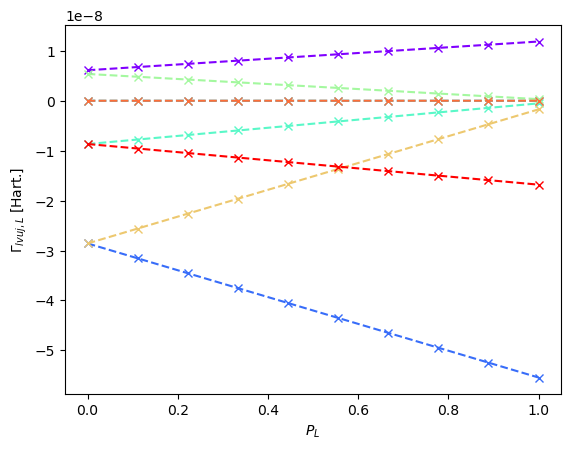

In [3]:

c =cm.rainbow(np.linspace(0, 1, 8))
plt.plot(PL, np.real(Ge00e), color=c[0],  marker='x', linestyle='None')
plt.plot(PL, np.real(GL0[1,2,2,1,0])*(1+PL*np.cos(theta)), color=c[0], linestyle='--')

plt.plot(PL, np.imag(Ge00e), color=c[1],  marker='x', linestyle='None')
plt.plot(PL, np.imag(GL0[1,2,2,1,0])*(1+PL*np.cos(theta)), color=c[1], linestyle='--')

plt.plot(PL, np.real(Ge22e), color=c[2],  marker='x', linestyle='None')
plt.plot(PL, np.real(GL0[1,3,3,1,0])*(1-PL*np.cos(theta)), color=c[2], linestyle='--')

plt.plot(PL, np.imag(Ge22e), color=c[3],  marker='x', linestyle='None')
plt.plot(PL, np.imag(GL0[1,3,3,1,0])*(1-PL*np.cos(theta)), color=c[3], linestyle='--')

plt.plot(PL, np.real(Gg00g), color=c[4],  marker='x', linestyle='None')
plt.plot(PL, np.real(GL0[0,2,2,0,0])*(1-PL*np.cos(theta)), color=c[4], linestyle='--')

plt.plot(PL, np.imag(Gg00g), color=c[5],  marker='x', linestyle='None')
plt.plot(PL, np.imag(GL0[0,2,2,0,0])*(1-PL*np.cos(theta)), color=c[5], linestyle='--')

plt.plot(PL, np.real(Gg22g), color=c[6],  marker='x', linestyle='None')
plt.plot(PL, np.real(GL0[0,3,3,0,0])*(1+PL*np.cos(theta)), color=c[6], linestyle='--')

plt.plot(PL, np.imag(Gg22g), color=c[7],  marker='x', linestyle='None')
plt.plot(PL, np.imag(GL0[0,3,3,0,0])*(1+PL*np.cos(theta)), color=c[7], linestyle='--')

plt.xlabel(r'$P_L$')
plt.ylabel(r'$\Gamma_{lvuj,L}$ [Hart.]')

The same holds for the rates where the indicies are flipped. 
$$
\Gamma_{veev,\alpha} = \Gamma_{veev,\alpha}^{P_\alpha=0} (1 \pm P_{\alpha} \cos\theta)\\
\Gamma_{vggv,\alpha} = \Gamma_{vggv,\alpha}^{P_\alpha=0} (1 \mp P_{\alpha} \cos\theta)
$$


Text(0, 0.5, '$\\Gamma_{lvuj,L}$ [Hart.]')

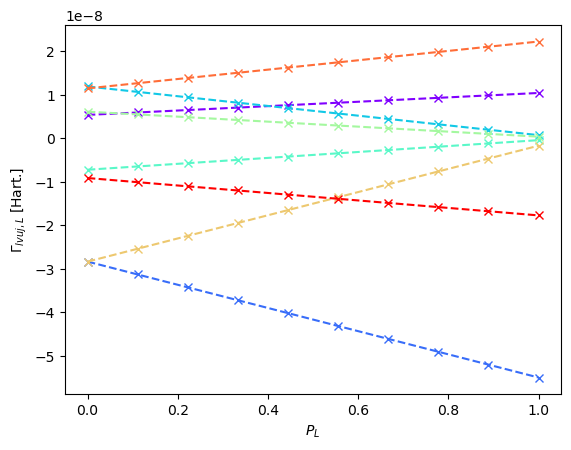

In [4]:

c =cm.rainbow(np.linspace(0, 1, 8))
plt.plot(PL, np.real(G0ee0), color=c[0],  marker='x', linestyle='None')
plt.plot(PL, np.real(GL0[2,1,1,2,0])*(1+PL*np.cos(theta)), color=c[0], linestyle='--')

plt.plot(PL, np.imag(G0ee0), color=c[1],  marker='x', linestyle='None')
plt.plot(PL, np.imag(GL0[2,1,1,2,0])*(1+PL*np.cos(theta)), color=c[1], linestyle='--')

plt.plot(PL, np.real(G2ee2), color=c[2],  marker='x', linestyle='None')
plt.plot(PL, np.real(GL0[3,1,1,3,0])*(1-PL*np.cos(theta)), color=c[2], linestyle='--')

plt.plot(PL, np.imag(G2ee2), color=c[3],  marker='x', linestyle='None')
plt.plot(PL, np.imag(GL0[3,1,1,3,0])*(1-PL*np.cos(theta)), color=c[3], linestyle='--')

plt.plot(PL, np.real(G0gg0), color=c[4],  marker='x', linestyle='None')
plt.plot(PL, np.real(GL0[2,0,0,2,0])*(1-PL*np.cos(theta)), color=c[4], linestyle='--')

plt.plot(PL, np.imag(G0gg0), color=c[5],  marker='x', linestyle='None')
plt.plot(PL, np.imag(GL0[2,0,0,2,0])*(1-PL*np.cos(theta)), color=c[5], linestyle='--')

plt.plot(PL, np.real(G2gg2), color=c[6],  marker='x', linestyle='None')
plt.plot(PL, np.real(GL0[3,0,0,3,0])*(1+PL*np.cos(theta)), color=c[6], linestyle='--')

plt.plot(PL, np.imag(G2gg2), color=c[7],  marker='x', linestyle='None')
plt.plot(PL, np.imag(GL0[3,0,0,3,0])*(1+PL*np.cos(theta)), color=c[7], linestyle='--')

plt.xlabel(r'$P_L$')
plt.ylabel(r'$\Gamma_{lvuj,L}$ [Hart.]')

Next we show $\Gamma_{evvg} = \Gamma_{gvve}$ for $v=0,2$. The relation breaks for large magnetic field, as you can see for there is already some discrepancy between $\Re\Gamma_{e00g}$ and  $\Re\Gamma_{g00e}$ (purple)

Text(0, 0.5, '$\\Gamma_{lvuj,L}$ [Hart.]')

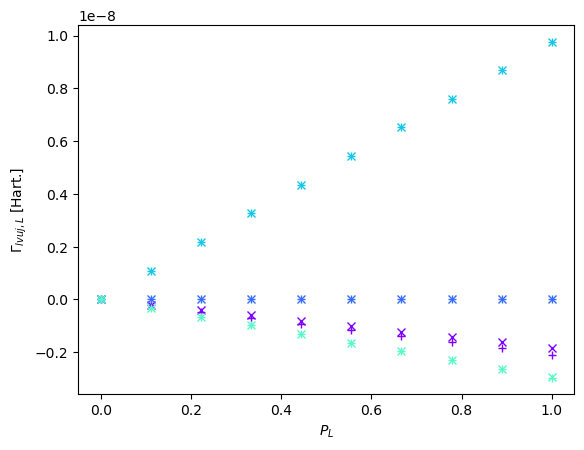

In [5]:
plt.plot(PL, np.real(Gg00e), color=c[0],  marker='+', linestyle='None')
plt.plot(PL, np.real(Ge00g), color=c[0],  marker='x', linestyle='None')

plt.plot(PL, np.real(Gg22e), color=c[1],  marker='+', linestyle='None')
plt.plot(PL, np.real(Ge22g), color=c[1],  marker='x', linestyle='None')

plt.plot(PL, np.imag(Gg00e), color=c[2],  marker='+', linestyle='None')
plt.plot(PL, np.imag(Ge00g), color=c[2],  marker='x', linestyle='None')

plt.plot(PL, np.imag(Gg22e), color=c[3],  marker='+', linestyle='None')
plt.plot(PL, np.imag(Ge22g), color=c[3],  marker='x', linestyle='None')

plt.xlabel(r'$P_L$')
plt.ylabel(r'$\Gamma_{lvuj,L}$ [Hart.]')


Finally the cancelation of the exchange field in the x and y direcition (perpendicular to polarization) depends on 
$$
P_{\alpha} \Im\{\Gamma_{g00g}^{P\alpha=0}-\Gamma_{g22g}^{P\alpha=0}\} = \sum_{v}\Im\{\Gamma_{evvg}\}
$$

Text(0, 0.5, '$\\Gamma_{lvuj,L}$ [Hart.]')

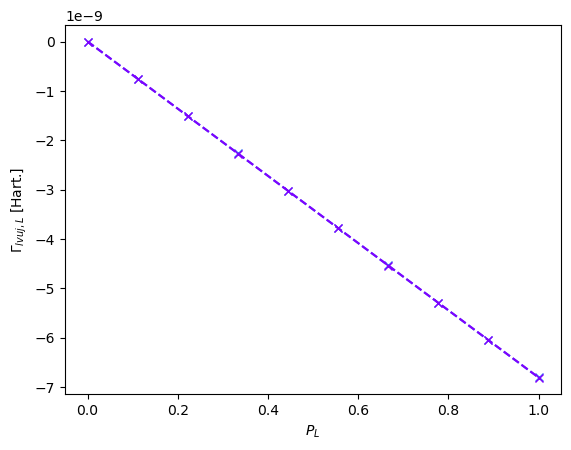

In [6]:

Ggvve = Gg00e + Gg22e
plt.plot(PL, -np.imag(Ggvve), color=c[1],  marker='x', linestyle='None')
plt.plot(PL, np.imag(GL0[0,2,2,0,0] - GL0[0,3,3,0,0])*(PL*np.sin(theta)), color=c[1], linestyle='--')

Gevvg  = Ge00g + Ge22g
plt.plot(PL, -np.imag(Gevvg), color=c[0],  marker='x', linestyle='None')
plt.plot(PL, np.imag(GL0[1,2,2,1,0] - GL0[1,3,3,1,0])*(PL*np.sin(theta)), color=c[0], linestyle='--')

plt.xlabel(r'$P_L$')
plt.ylabel(r'$\Gamma_{lvuj,L}$ [Hart.]')

In [7]:
eps= -30
U = 100
Nint = 1e4

Pl=.5

Vdc= -30
Left = Electrode(Vdc, 0, Pl, 1.25e-3, 1e-1, 4.5, Nint=Nint, Cutoff=1000, segments=[[dot.eps,30, Nint],[dot.U+dot.eps,30,Nint] ])
GLp, GLm = rates(dot, Left, 20, 0)
GL0 = GLp + GLm

thetas = np.linspace(0,2*np.pi,10)
Ge00e = np.empty_like(thetas, dtype=complex)
Ge22e = np.empty_like(thetas, dtype=complex)
Gg00g = np.empty_like(thetas, dtype=complex)
Gg22g = np.empty_like(thetas, dtype=complex)

G0gg0 = np.empty_like(thetas, dtype=complex)
G2gg2 = np.empty_like(thetas, dtype=complex)
G0ee0 = np.empty_like(thetas, dtype=complex)
G2ee2 = np.empty_like(thetas, dtype=complex)

Ge00g = np.empty_like(thetas, dtype=complex)
Gg00e = np.empty_like(thetas, dtype=complex)
Ge22g = np.empty_like(thetas, dtype=complex)
Gg22e = np.empty_like(thetas, dtype=complex)

for i, theta in enumerate(thetas): 
    B = 1*np.array([np.sin(theta),0,np.cos(theta)])
    dot = QD(eps, U, np.array([0.5]), [B], np.array([[2.0, 2.0, 2.0]]))
    
    GLp, GLm = rates(dot, Left, 20, 0)
    GL = GLp + GLm

    Gg00g[i] = GL[0,2,2,0,0] 
    Gg22g[i] = GL[0,3,3,0,0] 
    Ge00e[i] = GL[1,2,2,1,0] 
    Ge22e[i] = GL[1,3,3,1,0]

    G0gg0[i] = GL[2,0,0,2,0] 
    G2gg2[i] = GL[3,0,0,3,0] 
    G0ee0[i] = GL[2,1,1,2,0] 
    G2ee2[i] = GL[3,1,1,3,0] 
    
    Gg00e[i] = GL[0,2,2,1,0] 
    Ge00g[i] = GL[1,2,2,0,0] 
    Gg22e[i] = GL[0,3,3,1,0] 
    Ge22g[i] = GL[1,3,3,0,0] 


Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!


From the above we can conlclude that following terms of the form $\Gamma_{vggv} + \Gamma_{veev}$, and $\Gamma_{gvvg} + \Gamma_{evve}$ should be indepndent of the angle $\theta$ if the external field is small. 

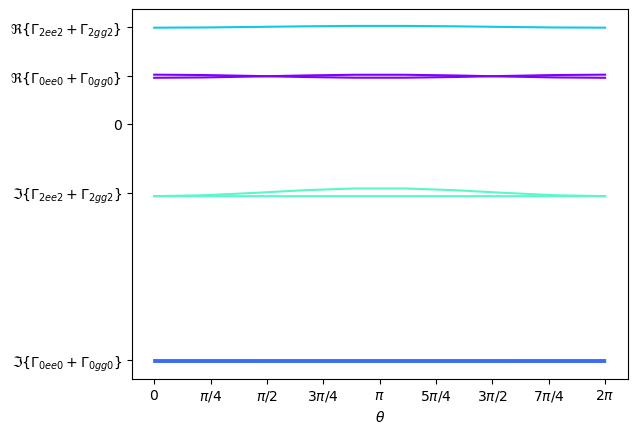

In [8]:
c =cm.rainbow(np.linspace(0, 1, 8))

plt.plot(thetas, np.real(G0ee0+G0gg0), color=c[0])
plt.plot(thetas, np.imag(G0ee0+G0gg0), color=c[1])
plt.plot(thetas, np.real(G2ee2+G2gg2), color=c[2])
plt.plot(thetas, np.imag(G2ee2+G2gg2), color=c[3])

plt.plot(thetas, np.real(Ge00e+Gg00g), color=c[0])
plt.plot(thetas, np.imag(Ge00e+Gg00g), color=c[1])
#plt.plot(thetas, np.real(Ge22e+Gg22g), color=c[2])
plt.plot(thetas, np.imag(Ge22e+Gg22g), color=c[3])


plt.xlabel(r'$\theta$')
plt.xticks(np.pi*np.array([0, 1/4, 1/2, 3/4, 1, 5/4, 3/2, 7/4, 2]), [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$',r'$\pi$', r'$5\pi/4$', r'$3\pi/2$', r'$7\pi/4$', r'$2\pi$',])
plt.yticks(np.mean(np.concat((np.zeros((1,len(G0ee0))), np.real([G0ee0+G0gg0, G2ee2+G2gg2]), np.imag([G0ee0+G0gg0, G2ee2+G2gg2]))), axis=1),
           [0, r'$\Re\{\Gamma_{0ee0}+\Gamma_{0gg0}\}$', r'$\Re\{\Gamma_{2ee2}+\Gamma_{2gg2}\}$', r'$\Im\{\Gamma_{0ee0}+\Gamma_{0gg0}\}$', r'$\Im\{\Gamma_{2ee2}+\Gamma_{2gg2}\}$'])
plt.show()

If we instead apply a ridicoulosly large magnetic field these relations break down

In [9]:
eps= -30
U = 100
Nint = 1e4

Pl=.5

Vdc= -30
Left = Electrode(Vdc, 0, Pl, 1.25e-3, 1e-1, 4.5, Nint=Nint, Cutoff=1000, segments=[[dot.eps,30, Nint],[dot.U+dot.eps,30,Nint] ])
GLp, GLm = rates(dot, Left, 20, 0)
GL0 = GLp + GLm

thetas = np.linspace(0,2*np.pi,10)
Ge00e = np.empty_like(thetas, dtype=complex)
Ge22e = np.empty_like(thetas, dtype=complex)
Gg00g = np.empty_like(thetas, dtype=complex)
Gg22g = np.empty_like(thetas, dtype=complex)

G0gg0 = np.empty_like(thetas, dtype=complex)
G2gg2 = np.empty_like(thetas, dtype=complex)
G0ee0 = np.empty_like(thetas, dtype=complex)
G2ee2 = np.empty_like(thetas, dtype=complex)

Ge00g = np.empty_like(thetas, dtype=complex)
Gg00e = np.empty_like(thetas, dtype=complex)
Ge22g = np.empty_like(thetas, dtype=complex)
Gg22e = np.empty_like(thetas, dtype=complex)

for i, theta in enumerate(thetas): 
    B = 100*np.array([np.sin(theta),0,np.cos(theta)])
    dot = QD(eps, U, np.array([0.5]), [B], np.array([[2.0, 2.0, 2.0]]))
    
    GLp, GLm = rates(dot, Left, 20, 0)
    GL = GLp + GLm

    Gg00g[i] = GL[0,2,2,0,0] 
    Gg22g[i] = GL[0,3,3,0,0] 
    Ge00e[i] = GL[1,2,2,1,0] 
    Ge22e[i] = GL[1,3,3,1,0]

    G0gg0[i] = GL[2,0,0,2,0] 
    G2gg2[i] = GL[3,0,0,3,0] 
    G0ee0[i] = GL[2,1,1,2,0] 
    G2ee2[i] = GL[3,1,1,3,0] 
    
    Gg00e[i] = GL[0,2,2,1,0] 
    Ge00g[i] = GL[1,2,2,0,0] 
    Gg22e[i] = GL[0,3,3,1,0] 
    Ge22g[i] = GL[1,3,3,0,0] 


Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!


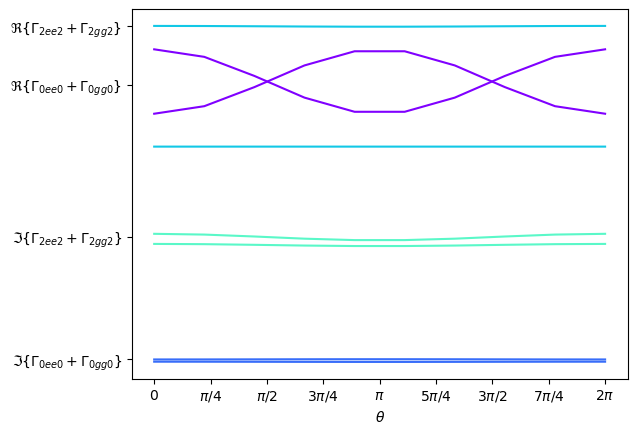

In [10]:
c =cm.rainbow(np.linspace(0, 1, 8))

plt.plot(thetas, np.real(G0ee0+G0gg0), color=c[0])
plt.plot(thetas, np.imag(G0ee0+G0gg0), color=c[1])
plt.plot(thetas, np.real(G2ee2+G2gg2), color=c[2])
plt.plot(thetas, np.imag(G2ee2+G2gg2), color=c[3])

plt.plot(thetas, np.real(Ge00e+Gg00g), color=c[0])
plt.plot(thetas, np.imag(Ge00e+Gg00g), color=c[1])
plt.plot(thetas, np.real(Ge22e+Gg22g), color=c[2])
plt.plot(thetas, np.imag(Ge22e+Gg22g), color=c[3])


plt.xlabel(r'$\theta$')
plt.xticks(np.pi*np.array([0, 1/4, 1/2, 3/4, 1, 5/4, 3/2, 7/4, 2]), [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$',r'$\pi$', r'$5\pi/4$', r'$3\pi/2$', r'$7\pi/4$', r'$2\pi$',])
plt.yticks(np.mean(np.concat((np.real([G0ee0+G0gg0, G2ee2+G2gg2]), np.imag([G0ee0+G0gg0, G2ee2+G2gg2]))), axis=1),
           [r'$\Re\{\Gamma_{0ee0}+\Gamma_{0gg0}\}$', r'$\Re\{\Gamma_{2ee2}+\Gamma_{2gg2}\}$', r'$\Im\{\Gamma_{0ee0}+\Gamma_{0gg0}\}$', r'$\Im\{\Gamma_{2ee2}+\Gamma_{2gg2}\}$'])
plt.show()